# 02 · Multiple regression: a four-factor model for a fund

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/02_multiple_regression.ipynb)

**Goal:** explain a fund’s returns with the market, size (SMB), value (HML) and momentum (MOM) factors.
Compute adjusted R², the F-test, AIC/BIC and a nested-model joint F-test, by hand and with `statsmodels`.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
df = pd.read_csv(DATA + "factor_returns.csv")
y = df["fund_excess"]
X4 = sm.add_constant(df[["mkt_excess", "smb", "hml", "mom"]])
m4 = sm.OLS(y, X4).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:            fund_excess   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     124.8
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           6.97e-41
Time:                        16:45:16   Log-Likelihood:                -232.26
No. Observations:                 120   AIC:                             474.5
Df Residuals:                     115   BIC:                             488.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1572      0.160      0.982      0.3

**Interpretation:** each slope is the change in the fund’s excess return for a 1-point move in that factor,
**holding the other factors constant**. Look at which t-statistics exceed ~2.

## Adjusted R² and the F-statistic by hand

In [3]:
n, k = int(m4.nobs), 4
R2 = m4.rsquared
adj = 1 - (n - 1) / (n - k - 1) * (1 - R2)
SSE = (m4.resid ** 2).sum(); SST = ((y - y.mean()) ** 2).sum(); SSR = SST - SSE
F = (SSR / k) / (SSE / (n - k - 1))
print(f"R2={R2:.4f}  adj R2={adj:.4f} (statsmodels {m4.rsquared_adj:.4f})")
print(f"F={F:.2f} (statsmodels {m4.fvalue:.2f}), p={m4.f_pvalue:.2e}")

R2=0.8127  adj R2=0.8062 (statsmodels 0.8062)
F=124.79 (statsmodels 124.79), p=6.97e-41


## Compare models with AIC and BIC (lower is better)

In [4]:
def fit(cols):
    return sm.OLS(y, sm.add_constant(df[cols])).fit()

models = {"CAPM": ["mkt_excess"], "3-factor": ["mkt_excess", "smb", "hml"], "4-factor": ["mkt_excess", "smb", "hml", "mom"]}
rows = []
for name, cols in models.items():
    r = fit(cols)
    sse = (r.resid ** 2).sum(); kk = len(cols)
    aic_cfa = n * np.log(sse / n) + 2 * (kk + 1)            # CFA formula
    bic_cfa = n * np.log(sse / n) + np.log(n) * (kk + 1)
    rows.append([name, r.rsquared, r.rsquared_adj, aic_cfa, bic_cfa])
pd.DataFrame(rows, columns=["model", "R2", "adj R2", "AIC (CFA)", "BIC (CFA)"]).set_index("model").round(3)

,R2,adj R2,AIC (CFA),BIC (CFA)
model,,,,
CAPM,0.676,0.673,193.679,199.254
3-factor,0.813,0.808,131.976,143.126
4-factor,0.813,0.806,133.969,147.907


Note: statsmodels’ `.aic` / `.bic` use the log-likelihood version; the **ranking** is the same as the CFA formula.

## Nested models: do SMB and HML add value jointly?
$F = \dfrac{(SSE_R - SSE_U)/q}{SSE_U/(n-k-1)}$ with *q* = 2 restrictions.

In [5]:
from scipy import stats
rest, unres = fit(["mkt_excess", "mom"]), m4
sse_r, sse_u, q = (rest.resid ** 2).sum(), (unres.resid ** 2).sum(), 2
F_joint = ((sse_r - sse_u) / q) / (sse_u / (n - k - 1))
print(f"F = {F_joint:.2f}, critical F(2,{n-k-1}) = {stats.f.ppf(0.95, q, n-k-1):.2f}")
print(m4.f_test("smb = 0, hml = 0"))          # same test in one line

F = 39.94, critical F(2,115) = 3.08
<F test: F=39.935403378639194, p=6.755940108747237e-14, df_denom=115, df_num=2>


## Diagnostic plot: residuals vs fitted

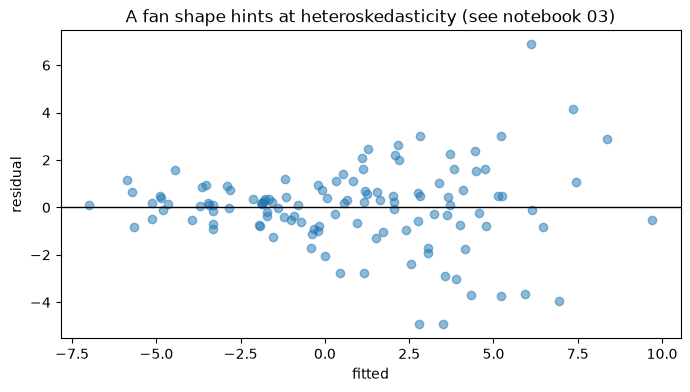

In [6]:
plt.scatter(m4.fittedvalues, m4.resid, alpha=0.5); plt.axhline(0, color="k", lw=1)
plt.xlabel("fitted"); plt.ylabel("residual"); plt.title("A fan shape hints at heteroskedasticity (see notebook 03)"); plt.show()

### Exercise 1

Is momentum significant for this fund at 5%? Store its t-stat in `mom_t` and `True`/`False` in `mom_significant`.

In [7]:
# Your code here

In [8]:
check("02.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 02.1: not answered yet. Store your answer in `mom_t`, `mom_significant`.


### Exercise 2

Add a useless random variable `noise = np.random.default_rng(0).normal(size=n)` to the 4-factor model. Store the new R² and adjusted R² in `r2_noise` and `adj_r2_noise`. What happened to each, and why?

In [9]:
# Your code here

In [10]:
check("02.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 02.2: not answered yet. Store your answer in `r2_noise`, `adj_r2_noise`.


### Exercise 3

Predict the fund’s excess return in a month where mkt = 2, smb = −1, hml = 0.5, mom = 1. Store the number in `pred_fund`.

<details><summary>Hint</summary>

`m4.predict(pd.DataFrame({'const':[1], 'mkt_excess':[2], 'smb':[-1], 'hml':[0.5], 'mom':[1]}))`

</details>

In [11]:
# Your code here

In [12]:
check("02.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 02.3: not answered yet. Store your answer in `pred_fund`.


---
## Solutions

In [13]:
mom_t, mom_significant = m4.tvalues["mom"], m4.pvalues["mom"] < 0.05
print("1) MOM t =", round(mom_t, 2), "p =", round(m4.pvalues["mom"], 3))
d2 = df.copy(); d2["noise"] = np.random.default_rng(0).normal(size=n)
r5 = sm.OLS(y, sm.add_constant(d2[["mkt_excess", "smb", "hml", "mom", "noise"]])).fit()
r2_noise, adj_r2_noise = r5.rsquared, r5.rsquared_adj
print(f"2) R2 {m4.rsquared:.4f} -> {r2_noise:.4f} (never falls); adj R2 {m4.rsquared_adj:.4f} -> {adj_r2_noise:.4f} (penalised)")
pred_fund = m4.predict(pd.DataFrame({"const": [1], "mkt_excess": [2], "smb": [-1], "hml": [0.5], "mom": [1]})).iloc[0]
print("3)", round(pred_fund, 3))
check_all("02")

1) MOM t = -0.08 p = 0.937
2) R2 0.8127 -> 0.8127 (never falls); adj R2 0.8062 -> 0.8045 (penalised)
3) 1.942


✅ Exercise 02.1: correct.
✅ Exercise 02.2: correct.
✅ Exercise 02.3: correct.

3 of 3 exercises correct.
